# Two Moons Laplace — 5-Seed Evaluation

Same variants as `two_moons_laplace.ipynb` but run over 5 random seeds. Checkpoints use `two_moons_laplace_5seed/` and figures use the `5seed_two_moons_` prefix.

In [22]:
from pathlib import Path
import sys, os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from laplace import Laplace

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (TinyMLP, train_map, checkpoint_exists, load_checkpoint,
                    save_checkpoint, load_two_moons, seed_everything, standard_metrics)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEEDS = [42, 711, 123, 456, 789]

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Separate checkpoint dir — no collision with single-seed two_moons_{vname}_seed42.pt
CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "two_moons_laplace_5seed")
os.makedirs(CHECKPOINT_BASE, exist_ok=True)

plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"5-seed Two Moons Laplace | {len(SEEDS)} seeds | checkpoints -> {CHECKPOINT_BASE}")


Device: cuda
5-seed Two Moons Laplace | 5 seeds | checkpoints -> /u/halle/carg/home_at/Documents/BNNs/results/checkpoints/two_moons_laplace_5seed


In [23]:
def plot_boundary(predict_fn, X_data, y_data, title, ax=None):
    h = 0.05
    x_min, x_max = X_data[:,0].min()-0.5, X_data[:,0].max()+0.5
    y_min, y_max = X_data[:,1].min()-0.5, X_data[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    probs = predict_fn(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    if ax is None:
        _, ax = plt.subplots(figsize=(5,4))
    ax.contourf(xx, yy, probs, levels=50, cmap="RdBu_r", alpha=0.8, vmin=0, vmax=1)
    ax.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=1.5)
    ax.scatter(X_data[:,0], X_data[:,1], c=y_data, cmap="bwr",
               edgecolors="k", linewidths=0.4, s=30, zorder=3)
    ax.set_title(title)

def la_predict_fn(la_v, device):
    def predict_fn(X_np):
        results = []
        with torch.no_grad():
            for i in range(0, len(X_np), 256):
                X_t = torch.tensor(X_np[i:i+256], dtype=torch.float32).to(device)
                p = la_v(X_t, pred_type="glm", link_approx="probit")
                results.append(p[:,1].detach().cpu())
        return torch.cat(results).numpy()
    return predict_fn

def build_laplace_variant(base_model, spec, device):
    variant_model = TinyMLP(hidden=64).to(device)
    variant_model.load_state_dict(base_model.state_dict())
    return Laplace(variant_model, "classification",
                   subset_of_weights=spec["subset_of_weights"],
                   hessian_structure=spec["hessian_structure"])

variant_specs = [
    {"variant_name": "gridsearch_diag_all_weights", "subset_of_weights": "all",
     "hessian_structure": "diag", "tune_method": "gridsearch",
     "plot_title": "Diag / all weights / gridsearch"},
    {"variant_name": "marglik_diag_all_weights", "subset_of_weights": "all",
     "hessian_structure": "diag", "tune_method": "marglik",
     "plot_title": "Diag / all weights / marglik"},
    {"variant_name": "gridsearch_full_all_weights", "subset_of_weights": "all",
     "hessian_structure": "full", "tune_method": "gridsearch",
     "plot_title": "Full / all weights / gridsearch"},
    {"variant_name": "marglik_full_all_weights", "subset_of_weights": "all",
     "hessian_structure": "full", "tune_method": "marglik",
     "plot_title": "Full / all weights / marglik"},
    {"variant_name": "gridsearch_kron_all_weights", "subset_of_weights": "all",
     "hessian_structure": "kron", "tune_method": "gridsearch",
     "plot_title": "Kron / all weights / gridsearch"},
    {"variant_name": "marglik_kron_all_weights", "subset_of_weights": "all",
     "hessian_structure": "kron", "tune_method": "marglik",
     "plot_title": "Kron / all weights / marglik"},
    {"variant_name": "gridsearch_full_last_layer", "subset_of_weights": "last_layer",
     "hessian_structure": "full", "tune_method": "gridsearch",
     "plot_title": "Full / last layer / gridsearch"},
    {"variant_name": "marglik_full_last_layer", "subset_of_weights": "last_layer",
     "hessian_structure": "full", "tune_method": "marglik",
     "plot_title": "Full / last layer / marglik"},
    {"variant_name": "gridsearch_kron_last_layer", "subset_of_weights": "last_layer",
     "hessian_structure": "kron", "tune_method": "gridsearch",
     "plot_title": "Kron / last layer / gridsearch"},
    {"variant_name": "marglik_kron_last_layer", "subset_of_weights": "last_layer",
     "hessian_structure": "kron", "tune_method": "marglik",
     "plot_title": "Kron / last layer / marglik"},
]
print(f"Configured {len(variant_specs)} variants x {len(SEEDS)} seeds = "
      f"{len(variant_specs)*len(SEEDS)} total fits")

Configured 10 variants x 5 seeds = 50 total fits


In [24]:
all_seed_metrics = {}   # {seed: {vname: metrics_dict}}
all_seed_probs   = {}   # {seed: {vname: test_probs (N,2)}}
all_seed_la      = {}   # {seed: {vname: fitted Laplace object}}

# OOD grid (same for all seeds — deterministic)
ext = 4.5
gx, gy = np.meshgrid(np.arange(-ext, ext, 0.1), np.arange(-ext, ext, 0.1))
ood_grid_np = np.c_[gx.ravel(), gy.ravel()]

for seed in SEEDS:
    print(f"\n{'='*55}\nSEED {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})\n{'='*55}")
    seed_everything(seed)

    data = load_two_moons(seed=seed, noise=0.3, batch_train=32, batch_eval=64, device=device)
    X_train = data["X_train"]; X_val = data["X_val"]; X_test = data["X_test"]
    y_train = data["y_train"]; y_val   = data["y_val"]; y_test = data["y_test"]
    train_loader = data["train_loader"]; val_loader = data["val_loader"]
    X_test_tensor = data["X_test_tensor"]
    y_test_np = y_test

    # ----- MAP -----
    map_ckpt = os.path.join(CHECKPOINT_BASE, f"two_moons_map_seed{seed}.pt")
    model, _, _ = train_map(
        TinyMLP(hidden=64).to(device), train_loader,
        epochs=300, checkpoint_path=map_ckpt, device=device)
    model.eval()

    seed_metrics, seed_probs = {}, {}
    for spec in variant_specs:
        vname = spec["variant_name"]
        ckpt_path = os.path.join(CHECKPOINT_BASE, f"two_moons_{vname}_seed{seed}.pt")

        la_v = build_laplace_variant(model, spec, device)
        loaded = False
        if checkpoint_exists(ckpt_path):
            payload = load_checkpoint(ckpt_path)
            if isinstance(payload, dict) and payload.get("la") is not None:
                la_v = payload["la"]; v_metrics = payload.get("metrics", {}); loaded = True
            elif isinstance(payload, dict) and payload.get("la_state_dict") is not None:
                try:
                    la_v.load_state_dict(payload["la_state_dict"])
                except (AttributeError, TypeError):
                    # last_layer variants need fit() to identify the last layer first
                    la_v.fit(train_loader)
                    la_v.load_state_dict(payload["la_state_dict"])
                v_metrics = payload.get("metrics", {})
                loaded = True

        if not loaded:
            t0 = time.time(); la_v.fit(train_loader)
            v_metrics = {
                "Fit_Time (s)": time.time()-t0,
                "Subset_Of_Weights": spec["subset_of_weights"],
                "Hessian_Structure": spec["hessian_structure"],
                "Tune_Method": spec["tune_method"],
            }
            t1 = time.time()
            if spec["tune_method"] == "gridsearch":
                la_v.optimize_prior_precision(
                    method="gridsearch", pred_type="glm",
                    link_approx="probit", val_loader=val_loader)
            else:
                la_v.optimize_prior_precision(method="marglik")
            v_metrics["Tune_Time (s)"] = time.time()-t1
            v_metrics["Prior_Precision"] = float(la_v.prior_precision.item())
            save_checkpoint({"la": la_v, "la_state_dict": la_v.state_dict(),
                             "metrics": v_metrics}, ckpt_path)

        t_inf = time.time()
        with torch.no_grad():
            v_test_probs = la_v(X_test_tensor, pred_type="glm",
                                link_approx="probit").detach().cpu().numpy()
        v_metrics["Inf_Time (s)"] = time.time() - t_inf
        row = {**v_metrics, **standard_metrics(v_test_probs, y_test_np)}
        seed_metrics[vname] = row
        seed_probs[vname]   = v_test_probs
        all_seed_la.setdefault(seed, {})[vname] = la_v
        print(f"  {vname}: Acc={row.get('Accuracy',float('nan')):.4f}  "
              f"NLL={row.get('NLL',float('nan')):.4f}  "
              f"ECE={row.get('ECE',float('nan')):.4f}")

    all_seed_metrics[seed] = seed_metrics
    all_seed_probs[seed]   = seed_probs

print(f"\nCompleted {len(SEEDS)} seeds x {len(variant_specs)} variants.")


SEED 42  (1/5)
  gridsearch_diag_all_weights: Acc=0.9200  NLL=0.1898  ECE=0.0101
  marglik_diag_all_weights: Acc=0.9200  NLL=0.1921  ECE=0.0159
  gridsearch_full_all_weights: Acc=0.9200  NLL=0.1898  ECE=0.0101
  marglik_full_all_weights: Acc=0.9200  NLL=0.3071  ECE=0.1523
  gridsearch_kron_all_weights: Acc=0.9200  NLL=0.1898  ECE=0.0101
  marglik_kron_all_weights: Acc=0.9200  NLL=0.2380  ECE=0.0855
  gridsearch_full_last_layer: Acc=0.9200  NLL=0.1898  ECE=0.0101
  marglik_full_last_layer: Acc=0.9200  NLL=0.2260  ECE=0.0703
  gridsearch_kron_last_layer: Acc=0.9200  NLL=0.1898  ECE=0.0101
  marglik_kron_last_layer: Acc=0.9200  NLL=0.2208  ECE=0.0637

SEED 711  (2/5)
  gridsearch_diag_all_weights: Acc=0.9235  NLL=0.2011  ECE=0.0148
  marglik_diag_all_weights: Acc=0.9235  NLL=0.2048  ECE=0.0248
  gridsearch_full_all_weights: Acc=0.9235  NLL=0.2011  ECE=0.0148
  marglik_full_all_weights: Acc=0.9235  NLL=0.3458  ECE=0.1846
  gridsearch_kron_all_weights: Acc=0.9235  NLL=0.2011  ECE=0.0148
  

In [25]:
metric_keys = ["Accuracy", "NLL", "Brier_Score", "ECE", "Fit_Time (s)", "Tune_Time (s)", "Inf_Time (s)"]

agg = {}
for spec in variant_specs:
    vname = spec["variant_name"]; agg[vname] = {}
    for mk in metric_keys:
        vals = [all_seed_metrics[s][vname].get(mk, float("nan")) for s in SEEDS]
        vals = [v for v in vals if not np.isnan(v)]
        agg[vname][f"{mk}_mean"] = float(np.mean(vals)) if vals else float("nan")
        agg[vname][f"{mk}_std"]  = float(np.std(vals))  if len(vals)>1 else 0.0

rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    row = {mk: f"{agg[vname][f'{mk}_mean']:.4f} ± {agg[vname][f'{mk}_std']:.4f}"
           for mk in metric_keys}
    rows.append(row)
summary_df = pd.DataFrame(rows, index=[s["plot_title"] for s in variant_specs])
summary_df.index.name = "Variant"
print(f"Two Moons Laplace — {len(SEEDS)}-seed metrics (mean ± std)")
display(summary_df)

agg_flat = [{"Variant": s["plot_title"], **agg[s["variant_name"]]} for s in variant_specs]
agg_df = pd.DataFrame(agg_flat).set_index("Variant")
os.makedirs("results/metrics", exist_ok=True)
agg_df.to_csv("results/metrics/two_moons_laplace_5seed_metrics.csv")
print("\nSaved to results/metrics/two_moons_laplace_5seed_metrics.csv")


Two Moons Laplace — 5-seed metrics (mean ± std)


,Accuracy,NLL,Brier_Score,ECE,Fit_Time (s),Tune_Time (s),Inf_Time (s)
Variant,,,,,,,
Diag / all weights / gridsearch,0.9139 ± 0.0089,0.2095 ± 0.0169,0.0627 ± 0.0057,0.0126 ± 0.0021,0.3014 ± 0.1027,5.4536 ± 1.7087,0.0219 ± 0.0017
Diag / all weights / marglik,0.9139 ± 0.0089,0.2112 ± 0.0159,0.0629 ± 0.0055,0.0170 ± 0.0054,0.2967 ± 0.1040,0.0740 ± 0.0332,0.0221 ± 0.0021
Full / all weights / gridsearch,0.9139 ± 0.0089,0.2095 ± 0.0169,0.0627 ± 0.0057,0.0125 ± 0.0021,1033.8591 ± 16.9441,13.7583 ± 1.7985,0.0350 ± 0.0035
Full / all weights / marglik,0.9139 ± 0.0089,0.3233 ± 0.0300,0.0887 ± 0.0096,0.1514 ± 0.0294,1051.2611 ± 17.6054,2.1829 ± 0.2682,0.0343 ± 0.0023
Kron / all weights / gridsearch,0.9139 ± 0.0089,0.2095 ± 0.0169,0.0627 ± 0.0057,0.0125 ± 0.0021,0.5495 ± 0.0481,7.1157 ± 1.9553,0.0228 ± 0.0020
Kron / all weights / marglik,0.9139 ± 0.0089,0.2576 ± 0.0212,0.0714 ± 0.0061,0.0844 ± 0.0231,0.5571 ± 0.0303,0.1420 ± 0.0307,0.0227 ± 0.0019
Full / last layer / gridsearch,0.9139 ± 0.0089,0.2095 ± 0.0169,0.0627 ± 0.0057,0.0125 ± 0.0021,11.0739 ± 1.8258,1.9365 ± 0.3420,0.0009 ± 0.0001
Full / last layer / marglik,0.9139 ± 0.0089,0.2377 ± 0.0155,0.0673 ± 0.0052,0.0601 ± 0.0156,10.9710 ± 1.4066,0.0867 ± 0.0061,0.0009 ± 0.0001
Kron / last layer / gridsearch,0.9139 ± 0.0089,0.2095 ± 0.0169,0.0627 ± 0.0057,0.0125 ± 0.0021,0.5009 ± 0.1084,2.8041 ± 0.6716,0.0007 ± 0.0001



Saved to results/metrics/two_moons_laplace_5seed_metrics.csv


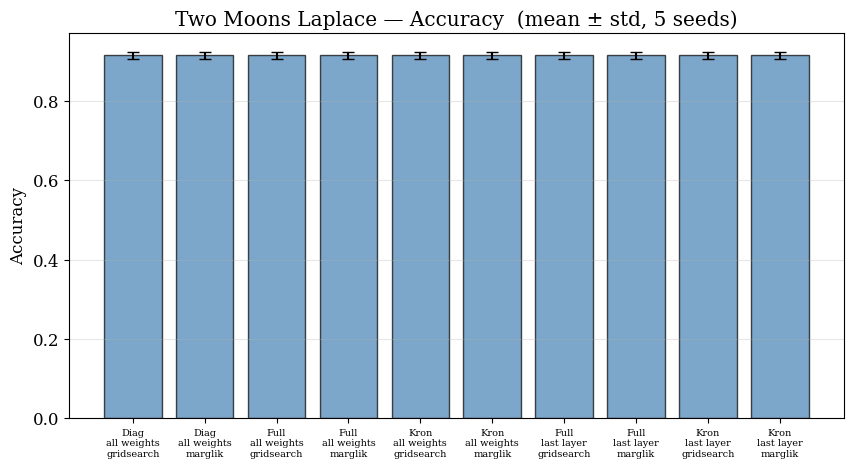

Saved: 5seed_two_moons_laplace_accuracy_bar.png


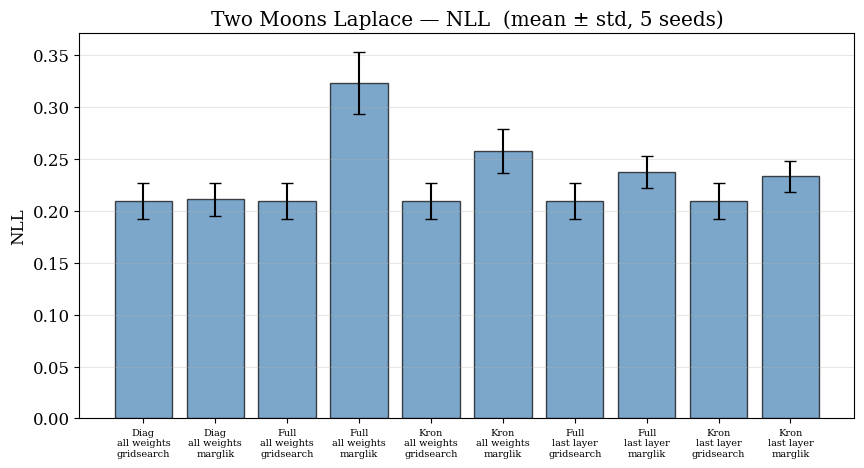

Saved: 5seed_two_moons_laplace_nll_bar.png


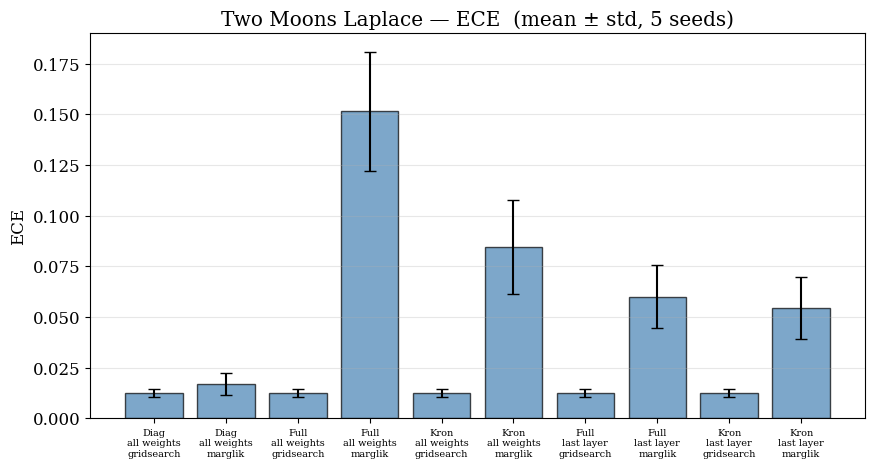

Saved: 5seed_two_moons_laplace_ece_bar.png


In [26]:
plot_metrics = ["Accuracy", "NLL", "ECE"]
titles = [s["plot_title"] for s in variant_specs]
x = np.arange(len(titles))

for mk in plot_metrics:
    means = [agg[s["variant_name"]][f"{mk}_mean"] for s in variant_specs]
    stds  = [agg[s["variant_name"]][f"{mk}_std"]  for s in variant_specs]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x, means, yerr=stds, capsize=4, color="steelblue", alpha=0.7, edgecolor="k")
    ax.set_xticks(x)
    ax.set_xticklabels([t.replace(" / ", "\n") for t in titles], fontsize=7)
    ax.set_ylabel(mk)
    ax.set_title(f"Two Moons Laplace — {mk}  (mean ± std, {len(SEEDS)} seeds)")
    ax.grid(True, alpha=0.3, axis="y")
    fname = f"5seed_two_moons_laplace_{mk.lower()}_bar.png"
    fig.savefig(os.path.join(FIGURES_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


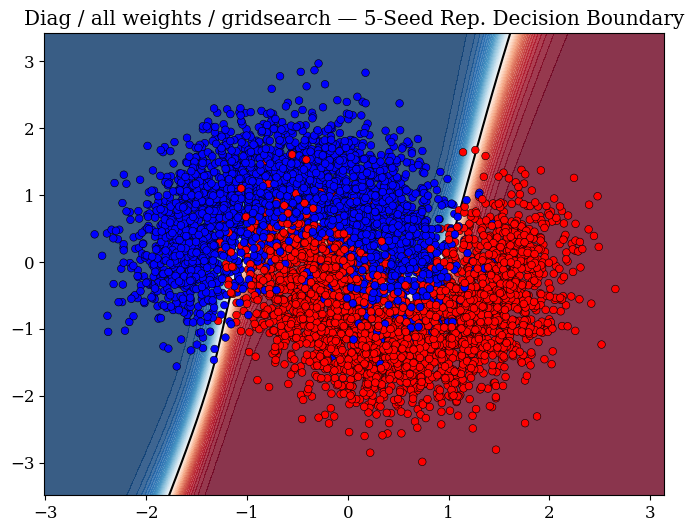

  Saved: 5seed_two_moons_gridsearch_diag_all_weights_boundary.png


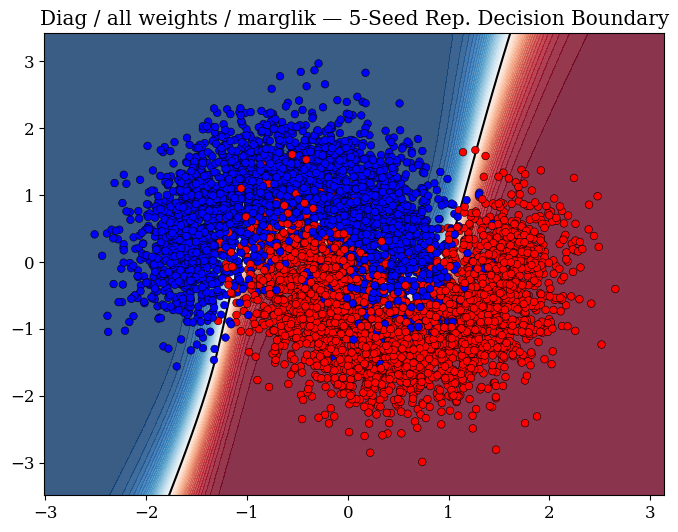

  Saved: 5seed_two_moons_marglik_diag_all_weights_boundary.png


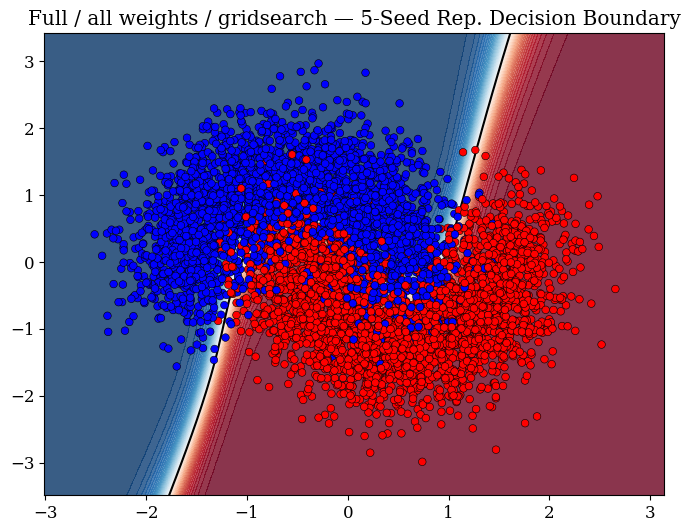

  Saved: 5seed_two_moons_gridsearch_full_all_weights_boundary.png


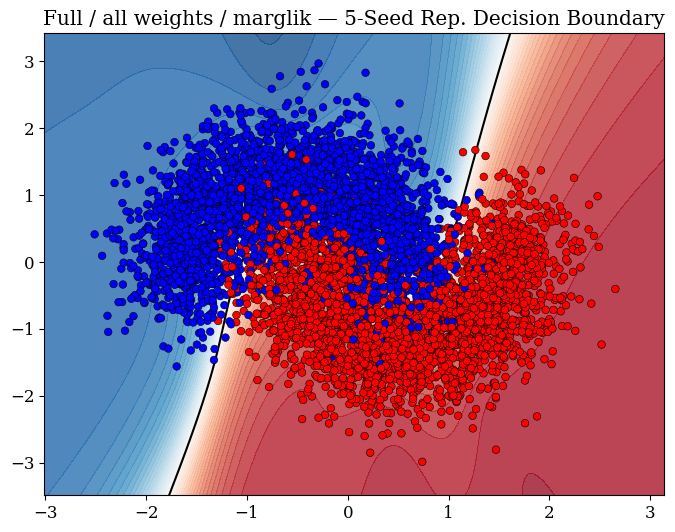

  Saved: 5seed_two_moons_marglik_full_all_weights_boundary.png


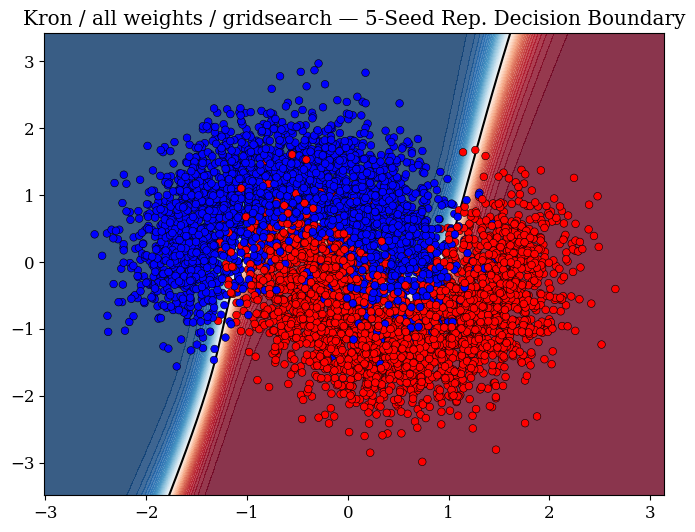

  Saved: 5seed_two_moons_gridsearch_kron_all_weights_boundary.png


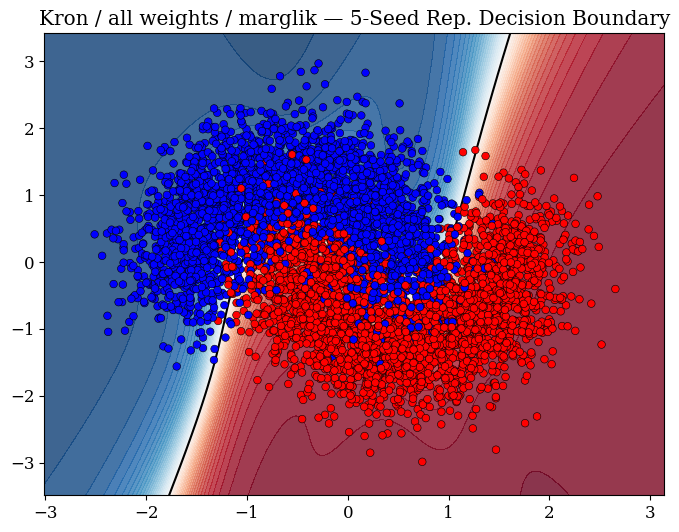

  Saved: 5seed_two_moons_marglik_kron_all_weights_boundary.png


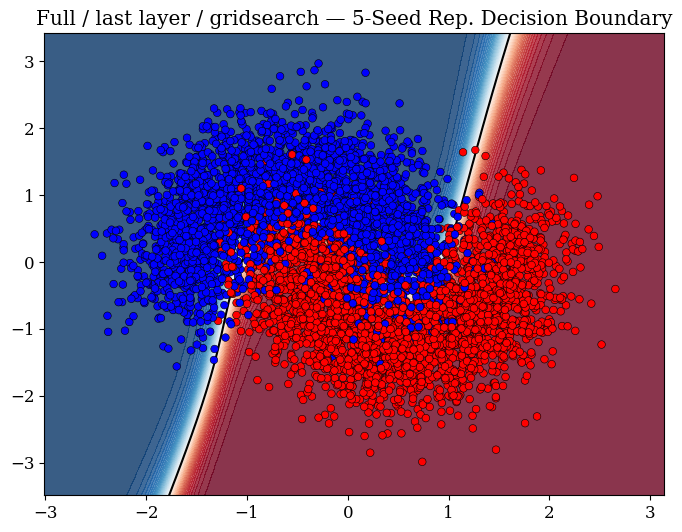

  Saved: 5seed_two_moons_gridsearch_full_last_layer_boundary.png


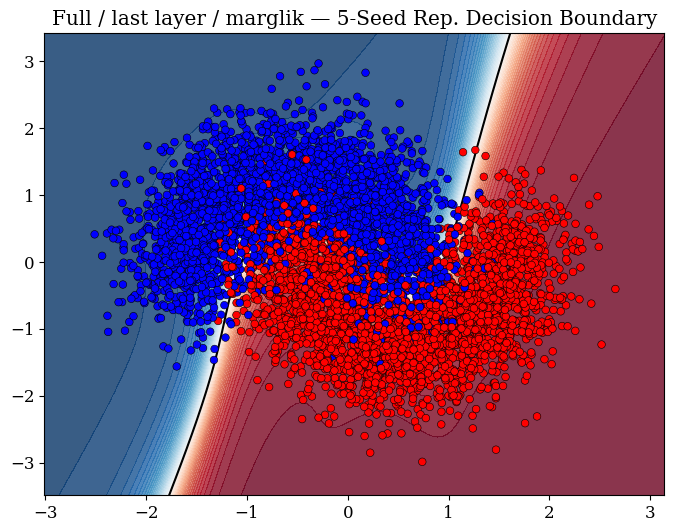

  Saved: 5seed_two_moons_marglik_full_last_layer_boundary.png


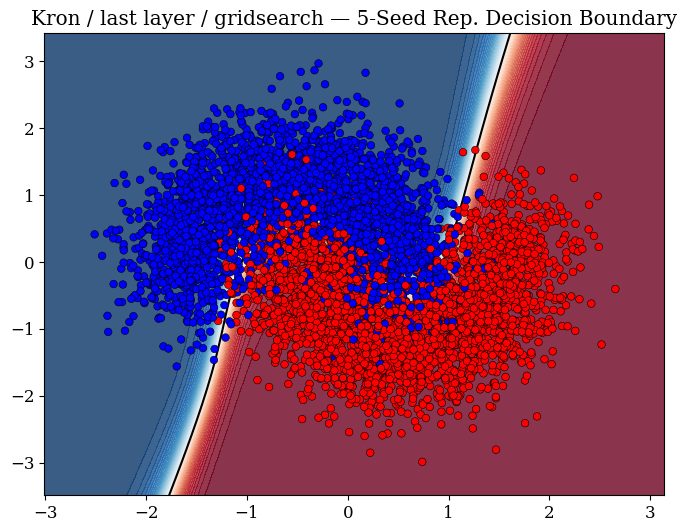

  Saved: 5seed_two_moons_gridsearch_kron_last_layer_boundary.png


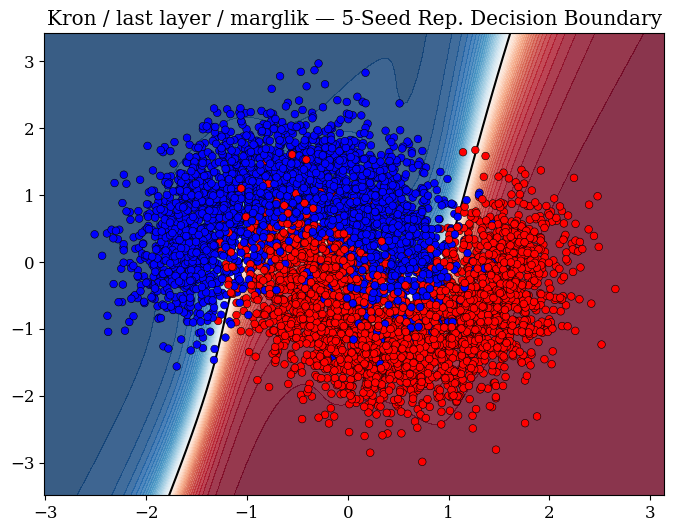

  Saved: 5seed_two_moons_marglik_kron_last_layer_boundary.png

Done: 10 boundary figures


In [27]:
# Per-variant representative decision boundary (last seed)
seed_last = SEEDS[-1]
data_last = load_two_moons(seed=seed_last, noise=0.3, batch_train=32, batch_eval=64, device=device)

for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    la_last = all_seed_la.get(seed_last, {}).get(vname)
    if la_last is None:
        print(f"  Skipping {vname} (not in memory)"); continue

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    predict_fn = la_predict_fn(la_last, device)
    plot_boundary(predict_fn, data_last["X_train"], data_last["y_train"],
                  f"{title} — 5-Seed Rep. Decision Boundary", ax=ax)
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_two_moons_{vname}_boundary.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_two_moons_{vname}_boundary.png")
print(f"\nDone: {len(variant_specs)} boundary figures")

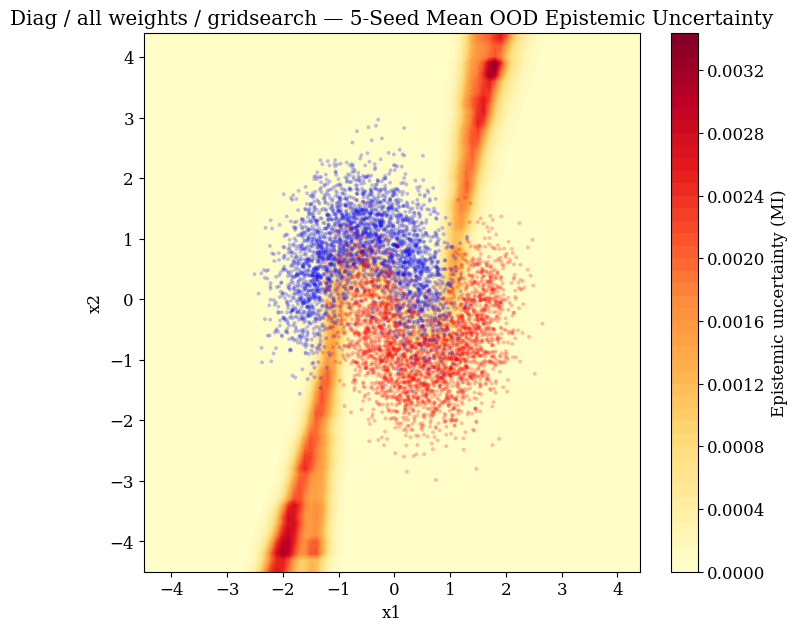

  Saved: 5seed_two_moons_gridsearch_diag_all_weights_ood_epistemic.png


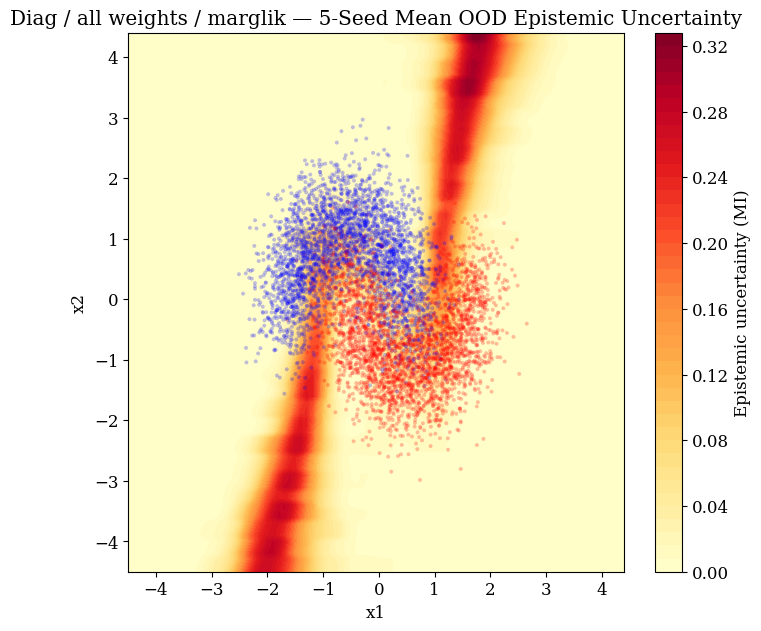

  Saved: 5seed_two_moons_marglik_diag_all_weights_ood_epistemic.png


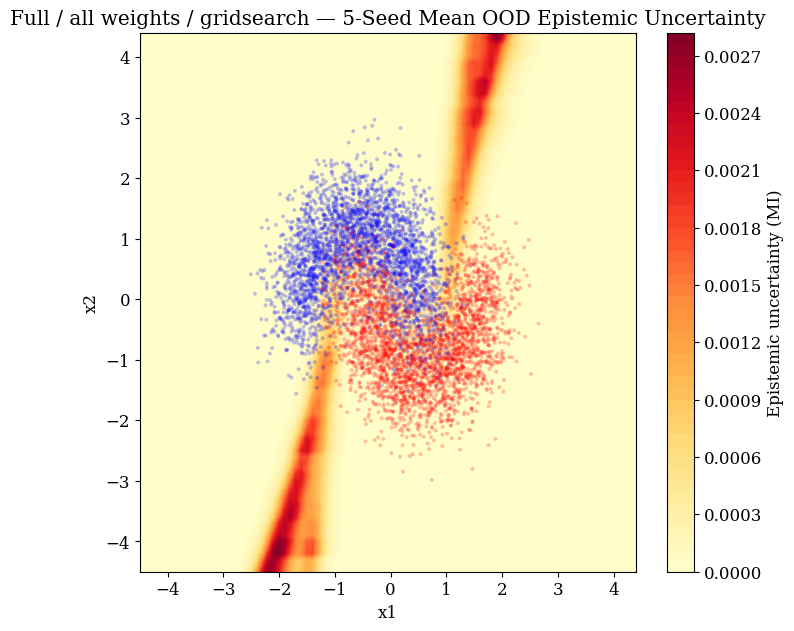

  Saved: 5seed_two_moons_gridsearch_full_all_weights_ood_epistemic.png


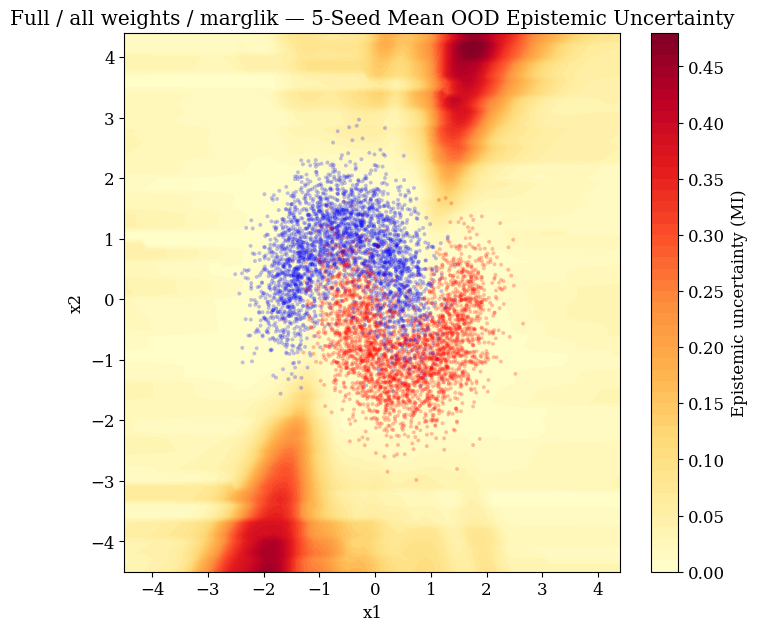

  Saved: 5seed_two_moons_marglik_full_all_weights_ood_epistemic.png


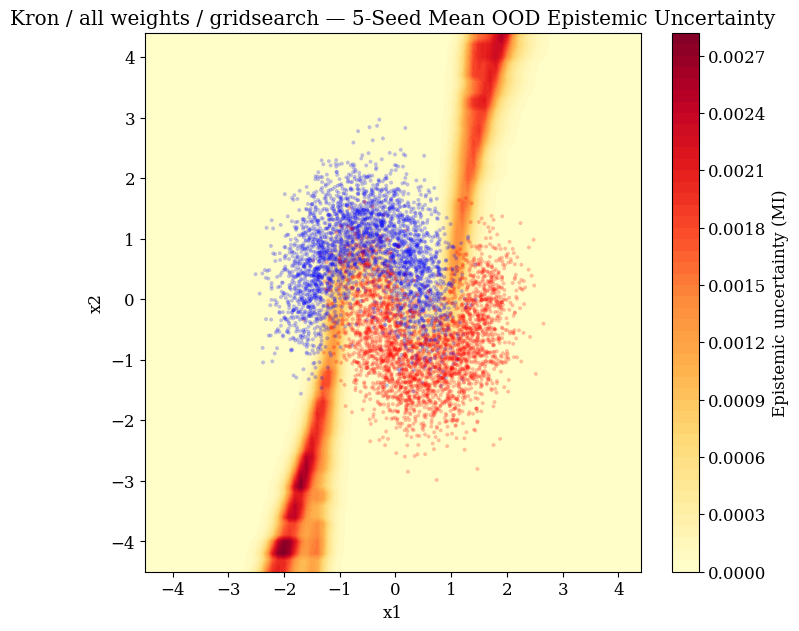

  Saved: 5seed_two_moons_gridsearch_kron_all_weights_ood_epistemic.png


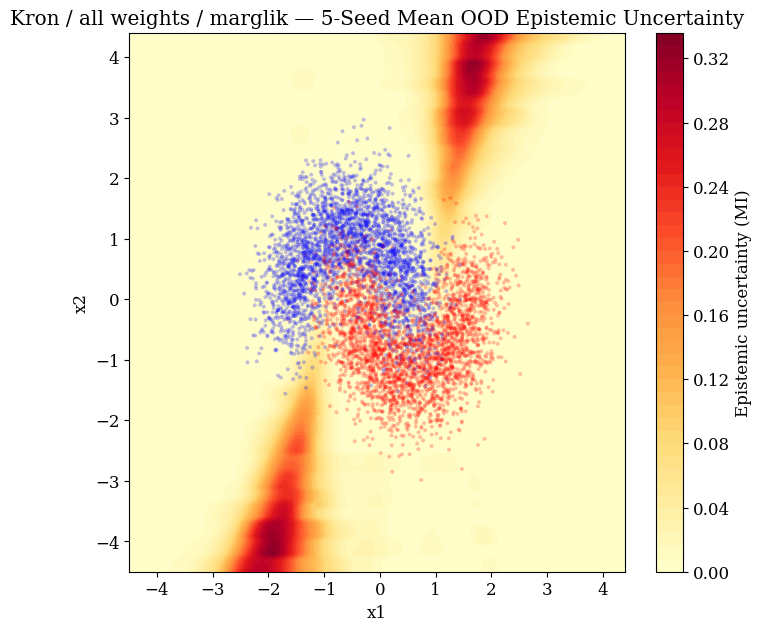

  Saved: 5seed_two_moons_marglik_kron_all_weights_ood_epistemic.png


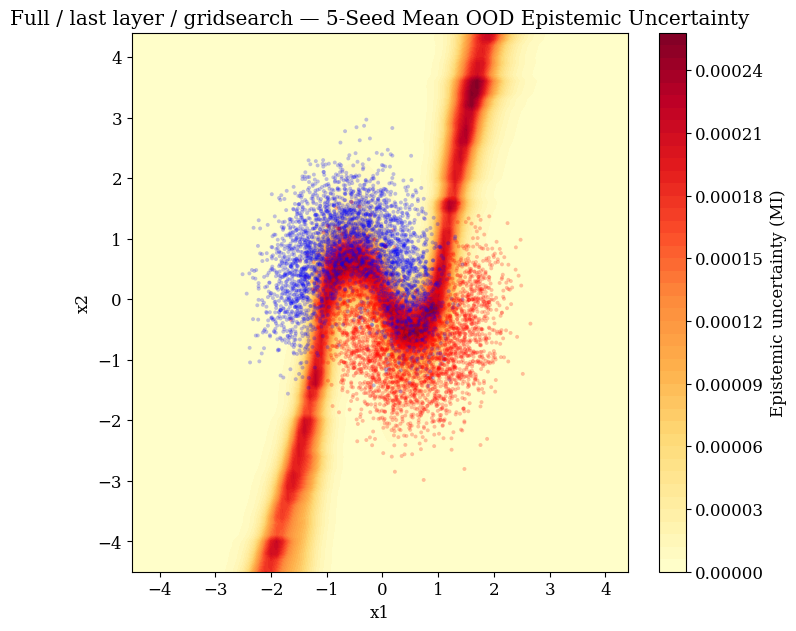

  Saved: 5seed_two_moons_gridsearch_full_last_layer_ood_epistemic.png


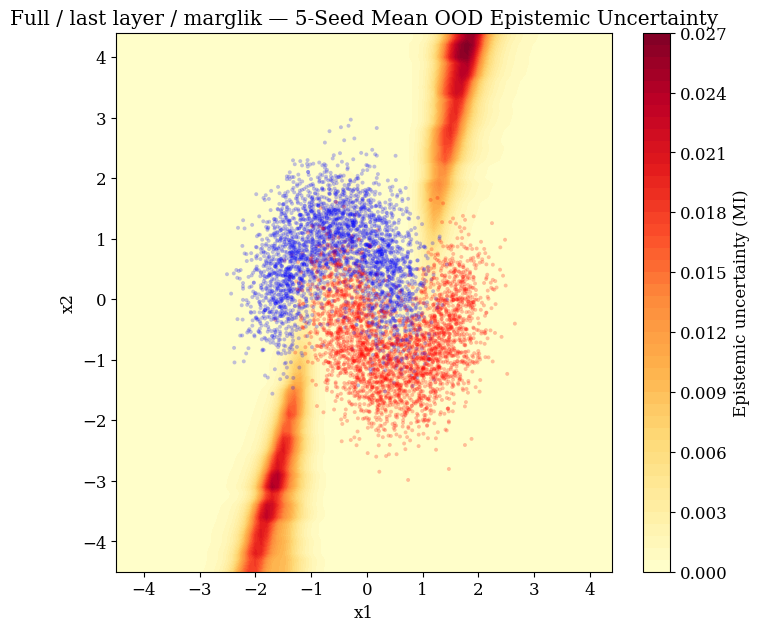

  Saved: 5seed_two_moons_marglik_full_last_layer_ood_epistemic.png


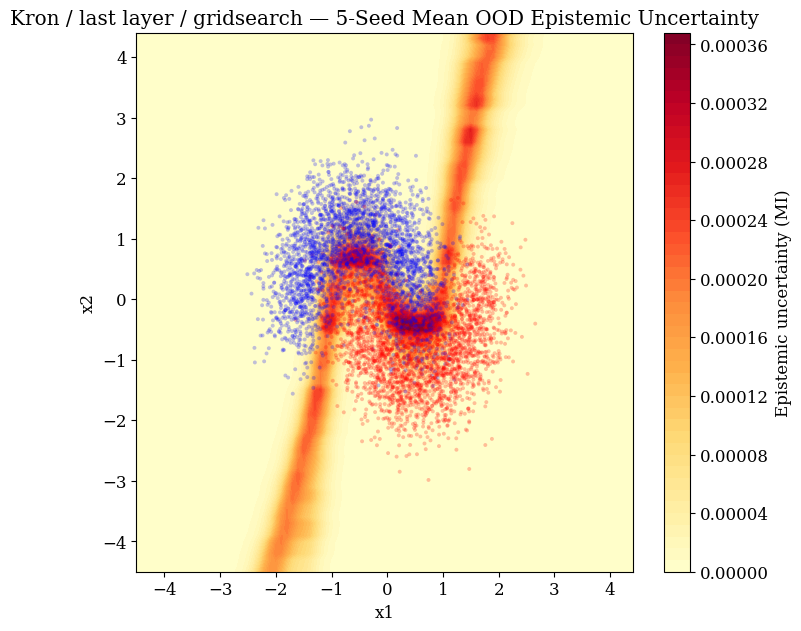

  Saved: 5seed_two_moons_gridsearch_kron_last_layer_ood_epistemic.png


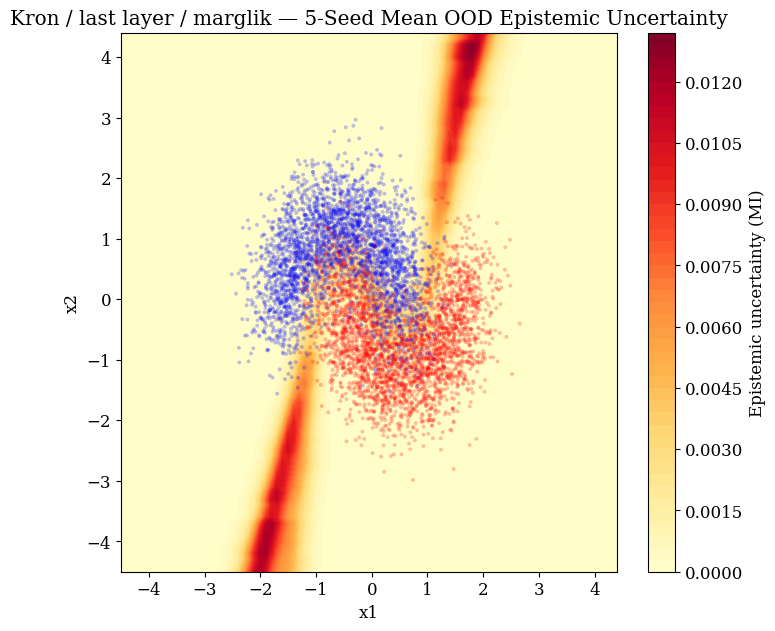

  Saved: 5seed_two_moons_marglik_kron_last_layer_ood_epistemic.png

Done: 10 OOD epistemic figures


In [28]:
# Per-variant OOD epistemic maps: average epistemic across seeds on a fixed grid
ood_grid_tensor = torch.tensor(ood_grid_np, dtype=torch.float32).to(device)

def _entropy(p):
    return -(p * np.log(p + 1e-12)).sum(axis=-1)

def epistemic_on_grid(la_v, grid_t, n_samples=50, batch_size=256):
    parts = []
    with torch.no_grad():
        for i in range(0, len(grid_t), batch_size):
            s = la_v.predictive_samples(grid_t[i:i+batch_size], pred_type="glm", n_samples=n_samples)
            parts.append(s.detach().cpu().numpy())
    samples = np.concatenate(parts, axis=1)
    mean_p = samples.mean(axis=0)
    return _entropy(mean_p) - _entropy(samples).mean(axis=0)

for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]

    all_epi_grids = []
    for seed in SEEDS:
        la_v_s = all_seed_la.get(seed, {}).get(vname)
        if la_v_s is None:
            continue
        epi = epistemic_on_grid(la_v_s, ood_grid_tensor)
        all_epi_grids.append(epi)

    if not all_epi_grids:
        print(f"  Skipping {vname} (no data)"); continue
    mean_epi = np.stack(all_epi_grids).mean(axis=0).reshape(gx.shape)

    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    cf = ax.contourf(gx, gy, mean_epi, levels=50, cmap="YlOrRd")
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap="bwr",
               s=8, alpha=0.25, edgecolors="none")
    plt.colorbar(cf, ax=ax, label="Epistemic uncertainty (MI)")
    ax.set_title(f"{title} — 5-Seed Mean OOD Epistemic Uncertainty")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_two_moons_{vname}_ood_epistemic.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_two_moons_{vname}_ood_epistemic.png")
print(f"\nDone: {len(variant_specs)} OOD epistemic figures")

/tmp/ipykernel_751010/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


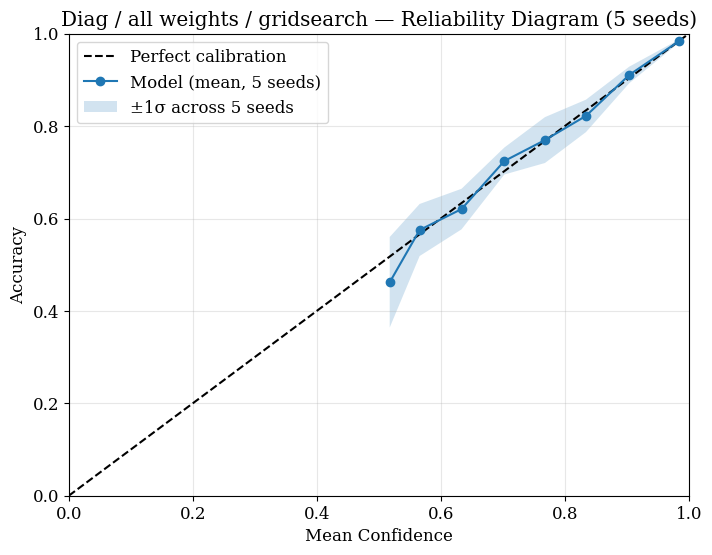

  Saved: 5seed_two_moons_gridsearch_diag_all_weights_reliability.png


/tmp/ipykernel_751010/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


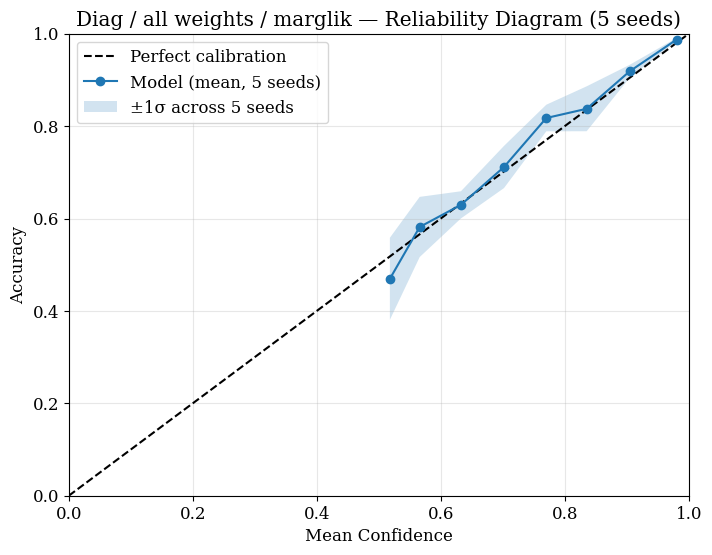

  Saved: 5seed_two_moons_marglik_diag_all_weights_reliability.png


/tmp/ipykernel_751010/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


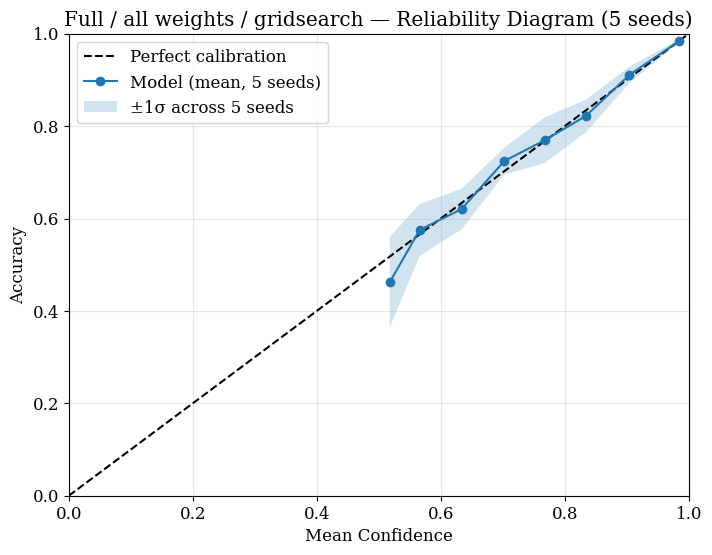

  Saved: 5seed_two_moons_gridsearch_full_all_weights_reliability.png


/tmp/ipykernel_751010/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


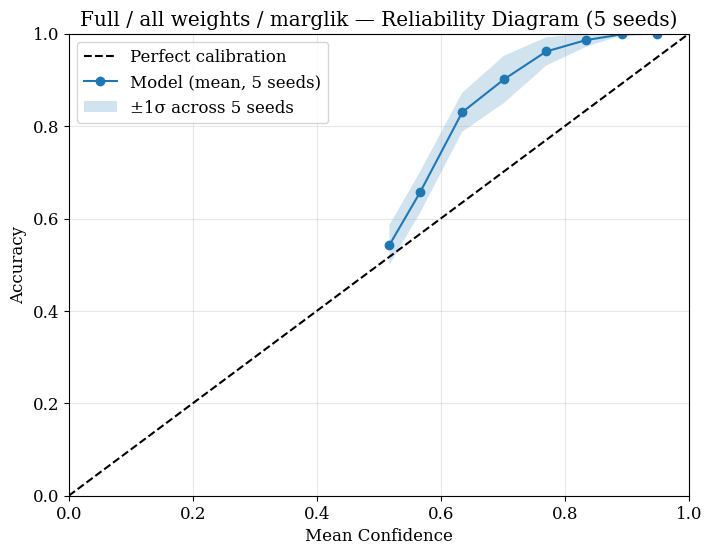

  Saved: 5seed_two_moons_marglik_full_all_weights_reliability.png


/tmp/ipykernel_751010/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


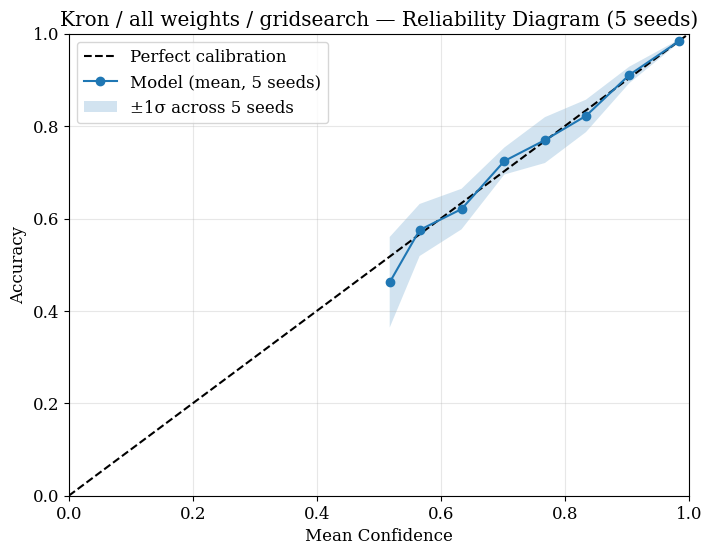

  Saved: 5seed_two_moons_gridsearch_kron_all_weights_reliability.png


/tmp/ipykernel_751010/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


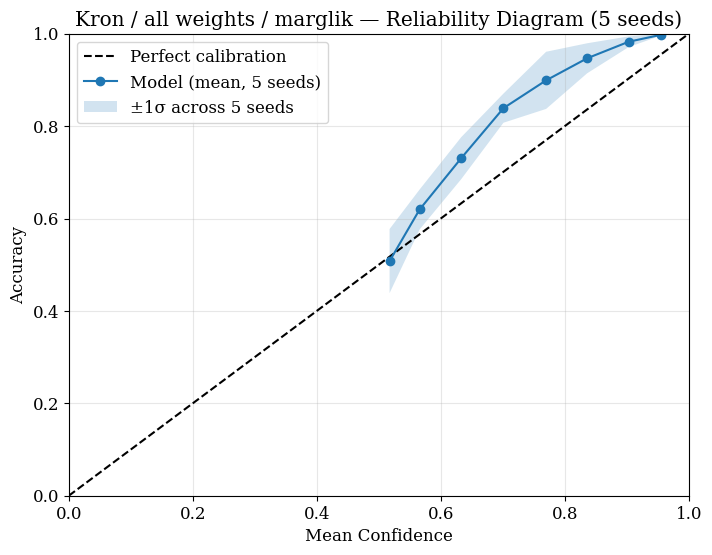

  Saved: 5seed_two_moons_marglik_kron_all_weights_reliability.png


/tmp/ipykernel_751010/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


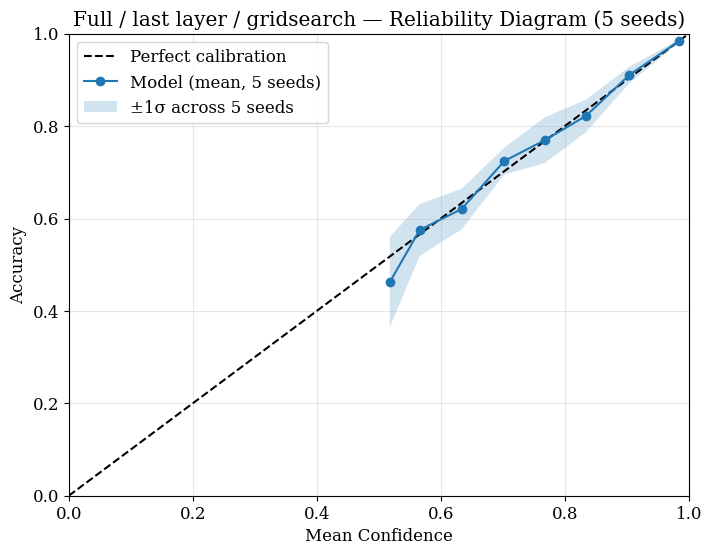

  Saved: 5seed_two_moons_gridsearch_full_last_layer_reliability.png


/tmp/ipykernel_751010/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


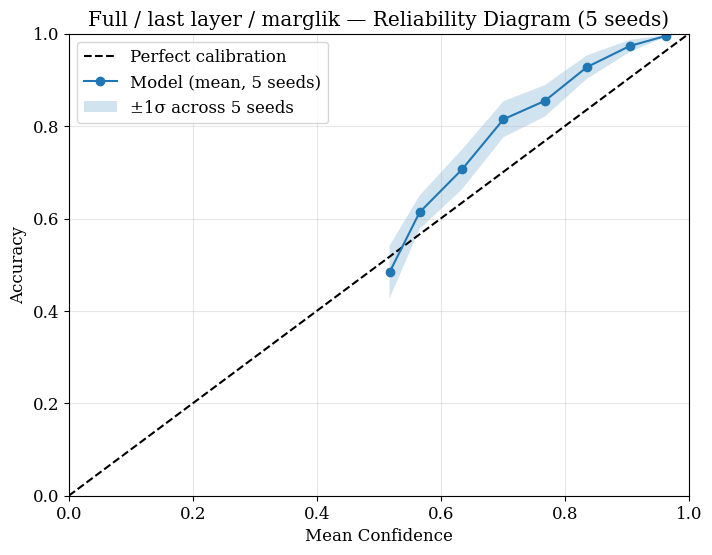

  Saved: 5seed_two_moons_marglik_full_last_layer_reliability.png


/tmp/ipykernel_751010/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


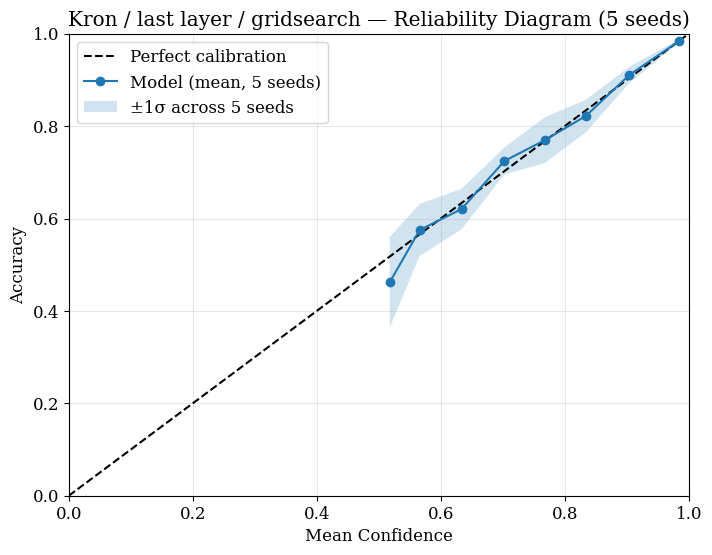

  Saved: 5seed_two_moons_gridsearch_kron_last_layer_reliability.png


/tmp/ipykernel_751010/2377971164.py:32: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


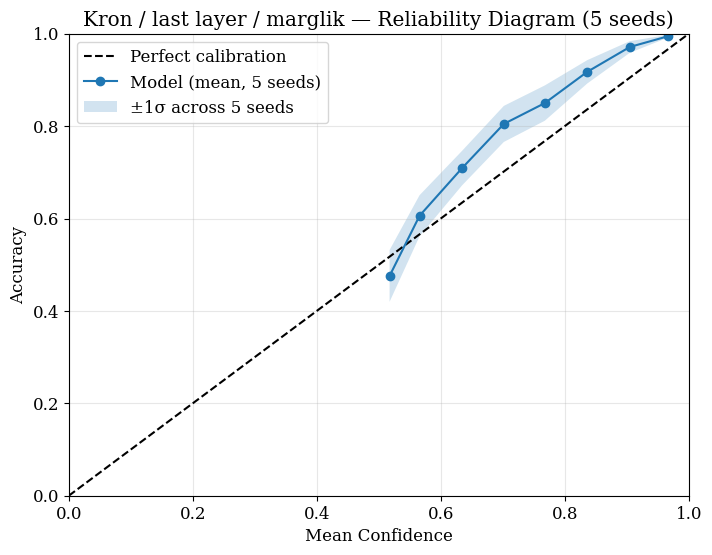

  Saved: 5seed_two_moons_marglik_kron_last_layer_reliability.png

Done: 10 reliability figures


In [29]:
# Per-variant reliability diagrams — mean ± std across seeds (ECE-style: confidence vs accuracy)
n_bins = 15
bins = np.linspace(0, 1, n_bins + 1)

for spec in variant_specs:
    vname = spec["variant_name"]
    title = spec["plot_title"]

    all_accs, all_confs = [], []
    for seed in SEEDS:
        probs = all_seed_probs.get(seed, {}).get(vname)
        if probs is None:
            continue
        data_s = load_two_moons(seed=seed, noise=0.3, batch_train=32, batch_eval=64, device=device)
        y_true = data_s["y_test"]
        conf = probs.max(axis=1)
        pred = probs.argmax(axis=1)
        accs_bin, confs_bin = [], []
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (conf > lo) & (conf <= hi)
            if mask.sum() == 0:
                accs_bin.append(np.nan)
                confs_bin.append((lo + hi) / 2)
            else:
                accs_bin.append(float((pred[mask] == y_true[mask]).mean()))
                confs_bin.append(float(conf[mask].mean()))
        all_accs.append(accs_bin)
        all_confs.append(confs_bin)

    all_accs  = np.array(all_accs)
    all_confs = np.array(all_confs)
    mean_obs  = np.nanmean(all_accs, axis=0)
    std_obs   = np.nanstd(all_accs, axis=0)
    mean_conf = np.nanmean(all_confs, axis=0)
    valid = ~np.isnan(mean_obs)

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(mean_conf[valid], mean_obs[valid], "o-", label=f"Model (mean, {len(SEEDS)} seeds)")
    ax.fill_between(mean_conf[valid],
                    (mean_obs - std_obs)[valid],
                    (mean_obs + std_obs)[valid],
                    alpha=0.2, label=f"±1σ across {len(SEEDS)} seeds")
    ax.set_xlabel("Mean Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{title} — Reliability Diagram ({len(SEEDS)} seeds)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_two_moons_{vname}_reliability.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_two_moons_{vname}_reliability.png")
print(f"\nDone: {len(variant_specs)} reliability figures")